# FPVS pypeline
###### The purpose of this script is to create an open source platform to process EEG data; similar to the letswave6 application in MATLAB. 
###### Author: Bhargav Pakhare (so far)

#### dependencies
 -> scipi.io     -> matplotlib  -> subprocess    ->ipyml 
 -> pathlib      -> numpy       -> mne
 -> h5py         -> pandas      -> importlib

### Wishlist
 1. Create a module for this pipeline where you only have to run a couple of functions to get the final product out
 2. Add functionality to take only those chunks where the signal is significantly greater than the baseline/noise in step 12
 3. Add a history section in the lw6 data that shows all the changes made to that particular file so that one doesnt have to hunt down all previous iterations of the file.


### Completed wishlist :
1. Add functionality for chanlocs and chan labels editing    DONE!
2. Always plot x,y and graph labels                          DONE! 
3. Create an interactive application to preprocess           Done, kind of, all plots are interactive
4. Make topographical maps that are interactive and make the channel locs light up in the topographical map when plotting the ft data.  DONE!
5. Reduce dependablity on MATLAB by changing the format of data from matlab style to python style  DONE!


### Changes I have made: 
1. Downsampling the data has changed its position to make things easier
2. ICA is done before segmentation, just to avoid stitching back data to perform ICA and then breaking it apart again after ICA
3. LW6 data renamed mdata, and the fields are updated to reflect a few fields which are easier to access as compared to matlab

In [ ]:
## UI for datafile selection for when we start with GUI
from ipyfilechooser import FileChooser
fc = FileChooser()
display(fc)
# This will now contain the path string
filepath = (fc.selected)
print(filepath)

## 0. import data files and relevant libraries


Variables in file: ['data']
the keys are: ('filetype', 'name', 'tags', 'history', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events')
the new data types are: [('filetype', '|O'), ('name', '|O'), ('tags', '|O'), ('history', '|O'), ('datasize', '|O'), ('xstart', '|O'), ('ystart', '|O'), ('zstart', '|O'), ('xstep', '|O'), ('ystep', '|O'), ('zstep', '|O'), ('chanlocs', '|O'), ('events', '|O'), ('fs', 'O'), ('activation', 'O')]
D:\Goffaux lab\Data set\Python_CSVfiles\BEFR2711


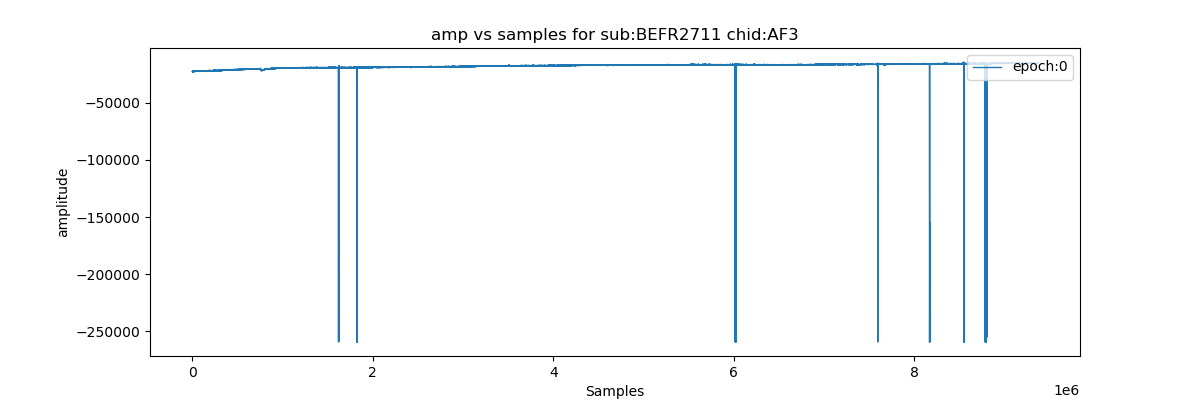

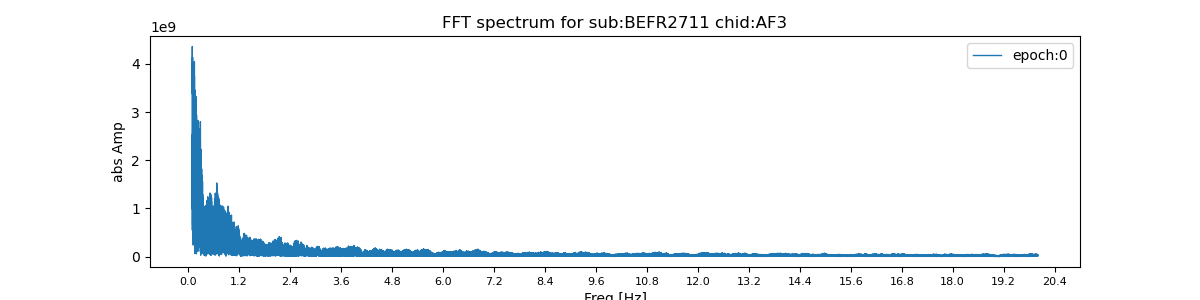

In [3]:
# wish list:
# 1. Add functionality for chanlocs and labels editing in this script
%reset -f
import scipy.io as sci
from pathlib import Path
import h5py
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import math
from collections import Counter
import importlib
import cust_funcs as cf
importlib.reload(cf)
import ipympl

folderpath=Path("D:\Goffaux lab\Data set\Python_CSVfiles\BEFR2711.mat")
subjid=folderpath.stem
# folderpath=filepath
matfilepath=folderpath.with_suffix(".mat")
lw6filepath=folderpath.with_suffix(".lw6")
lw6_data=sci.loadmat(lw6filepath)

# load the file only after altering channel labels
with h5py.File(matfilepath, 'r') as f:
    # List all variables
    print("Variables in file:", list(f.keys()))
    mat_data=f['data'][:]

# This section cleans the data and meta data to make it more python friendly

cleanlw6_data=cf.rebrand_lw6data(lw6_data,lw6filepath) 
lw6_data=cleanlw6_data.copy()

mat_data=np.squeeze(mat_data)
lw6filepath=lw6filepath.with_name(lw6filepath.stem + " mdata")
matfilepath=matfilepath.with_name(matfilepath.stem)
print(matfilepath)

np.save(lw6filepath,lw6_data)
np.save(matfilepath,mat_data)

chid=3
cf.showmeSummaryPlot(mat_data[:,chid-1],fs=np.squeeze(lw6_data["fs"]),chname=lw6_data["chanlocs"][0][0]["labels"][chid-1],subjid=subjid)

## 1. Rename channels

In [ ]:
labels = lw6_data["chanlocs"][0][0]["labels"]
targets = ["EXG1", "EXG2", "EXG3", "EXG4"]
replacements = ["I1", "I2", "PO9", "PO10"]

idx = np.where(np.isin(labels, targets))[0]
labels[idx] = replacements

lw6_data["chanlocs"][0][0]["labels"] = labels
lw6filepath = lw6filepath.with_name("1_chanlabels " + lw6filepath.stem)
matfilepath = matfilepath.with_name("1_chanlabels " + matfilepath.stem)
np.save(lw6filepath, lw6_data)
np.save(matfilepath, mat_data)
print("channels are renamed and saved in and as: ", lw6filepath.stem)

## 2. Electrode locations change

In [ ]:
electrodePath=Path("D:\Goffaux lab\letswave6_TR\\resources\electrodes\spherical_locations\\biosemi_locations_64_10-20_fixP9P10_add4.xyz")
electrode_data = np.loadtxt(electrodePath, dtype=str,max_rows=68)

Xcord=electrode_data[:,1]
Xcord=np.append(Xcord,['0','0','0','0','0']) #for some reason, there are 70 channels with only 68 entries so appending zeros 
Xcord=Xcord.astype(float)

Ycord=electrode_data[:,2]
Ycord=np.append(Ycord,['0','0','0','0','0']) #for some reason, there are 70 channels with only 68 entries so appending zeros 
Ycord=Ycord.astype(float)

Zcord=electrode_data[:,3]
Zcord=np.append(Zcord,['0','0','0','0','0']) #for some reason, there are 70 channels with only 68 entries so appending zeros 
Zcord=Zcord.astype(float)

def cart_to_sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = 0 if x==0 else np.arctan2(y, x)      # azimuth #if x=y=z=0 make angle also zeros
    phi = 0 if r==0 else np.arcsin(z / r)        # elevation  #if x=y=z=0 make angle also zeros  
    return r, theta, phi

r=np.zeros(len(Xcord))
theta=np.zeros(len(Xcord))
phi=np.zeros(len(Xcord))
theta_besa=np.zeros(len(Xcord))
phi_besa=np.zeros(len(Xcord))

for chid in range(len(Xcord)):
    r[chid],theta[chid],phi[chid]=cart_to_sph(Xcord[chid],Ycord[chid],Zcord[chid])
    theta_besa[chid]=.5*np.pi-theta[chid]
    phi_besa[chid]=.5*np.pi-phi[chid]


chanlocs=lw6_data["chanlocs"][0][0]
# print(chanlocs.dtype)
new_fields = [
    ('radius','O'),
    ('sph_theta', 'O'),
    ('sph_phi', 'O'),
    ('sph_theta_besa', 'O'),
    ('sph_phi_besa', 'O'),
    ('X', 'O'),
    ('Y', 'O'),
    ('Z', 'O')
]
new_dtype = chanlocs.dtype.descr + new_fields
new_chanlocs=np.zeros(chanlocs.shape,dtype=new_dtype)

for name in chanlocs.dtype.names:
    new_chanlocs[name]=chanlocs[name]

X = np.array([np.array([x]) for x in Xcord], dtype=object).T
Y = np.array([np.array([y]) for y in Ycord], dtype=object).T
Z = np.array([np.array([z]) for z in Zcord], dtype=object).T
r = np.array([np.array([x]) for x in r], dtype=object).T
phi = np.array([np.array([y]) for y in phi], dtype=object).T
theta = np.array([np.array([z]) for z in theta], dtype=object).T
phi_besa = np.array([np.array([x]) for x in phi_besa], dtype=object).T
theta_besa = np.array([np.array([y]) for y in theta_besa], dtype=object).T

new_chanlocs['radius'] = r
new_chanlocs['sph_phi'] = phi
new_chanlocs['sph_theta'] = theta
new_chanlocs['sph_phi_besa'] = phi_besa
new_chanlocs['sph_theta_besa'] = theta_besa
new_chanlocs['X'] = X
new_chanlocs['Y'] = Y
new_chanlocs['Z'] = Z

lw6_data["chanlocs"][0][0]=new_chanlocs
print(lw6_data["chanlocs"][0][0]["labels"])
lw6filepath=lw6filepath.with_name("2_chanlocs " + lw6filepath.stem )
matfilepath=matfilepath.with_name("2_chanlocs " + matfilepath.stem)
np.save(lw6filepath,lw6_data)
np.save(matfilepath,mat_data)
print("data is saved")

## 3. downsampling 
##### Since the sampling rate is higher than required for freq domain analysis, we downsample the signal to save space and make data more managable

In [ ]:
print(len(labels))

In [ ]:
dsfact=8 #downsampling factor
ndpts=mat_data.shape[0] #number of data points
nch=mat_data.shape[1] #number of channels
print("num of datapoints:", {ndpts})
print("num of channels:", {nch})
print("size of matrix:", {mat_data.shape})

ds_data=np.zeros((ndpts//dsfact, nch))
# print(ndpts//dsfact)

dsampind=range(0,ndpts,dsfact)
ds_data[:, :70] = mat_data[dsampind, :70]

print("size of new matrix:",ds_data.size)

# saving the data file
mat_data=ds_data.copy()
del ds_data

matfilepath = matfilepath.with_name("3_ds " + matfilepath.stem  )
np.save(matfilepath,mat_data)

#saving lw6_file
lw6filepath=lw6filepath.with_name("3_ds " + lw6filepath.stem )
lw6_data["fs"]=int(lw6_data["fs"])//dsfact
np.save(lw6filepath,lw6_data)
print("file saved as:",matfilepath)

chid=3
cf.showmeSummaryPlot(mat_data[:,chid-1],fs=np.squeeze(lw6_data["fs"]),chname=lw6_data["chanlocs"][0][0]["labels"][chid-1],subjid=subjid)

## 4. channel select
##### remove useless/dead channels from consideration

In [ ]:
# del labels
# del channel_names

chlabels=np.squeeze(lw6_data["chanlocs"][0][0]["labels"])

print(chlabels)

count=0
deletechid=[]
exgindices = np.where(np.char.find(np.char.lower(chlabels), 'ex') != -1)[0]
statindice = np.where(np.char.find(np.char.lower(chlabels), 'status') != -1)[0]

# for chid in range(chlabels.shape[0]-1,0,-1):
#     chrecording=mat_data[:,chid]
#     if all(x == 0 for x in chrecording):
#         print(chid)
#         deletechid.append(chid)

todeletechid=np.union1d(exgindices,statindice)
todeletechid=todeletechid.astype(int)
print(todeletechid)
lw6_datanew=lw6_data.copy()
chanlocs = lw6_data["chanlocs"][0][0]
mask = np.ones(len(chlabels), dtype=bool)
mask[todeletechid] = False

#deleting data
mat_data=mat_data[:,mask]

upd_chanlocs = np.delete(lw6_data["chanlocs"][0][0],todeletechid)
lw6_datanew["chanlocs"][0] = [upd_chanlocs]
lw6_data=lw6_datanew.copy()
print(upd_chanlocs)

lw6filepath=lw6filepath.with_name("4_chan-select " + lw6filepath.stem )
matfilepath=matfilepath.with_name("4_chan-select " + matfilepath.stem)
np.save(lw6filepath,lw6_data)
np.save(matfilepath,mat_data)

## 5&6.Band pass and notch filtering 
###### Removing low and high frequency noise
###### Removing line noise and its harmonics (n50 Hz)

In [ ]:
fs=int(np.squeeze(lw6_data["fs"]))
mat_data=mat_data.copy()

lowcut = 0.05
highcut = 100
order = 4
nch = mat_data.shape[1]
# Design Butterworth bandpass filter
slope= 2
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(order, [low, high], btype='band')
bn, an = iirnotch(50, slope, fs)
bn2, an2 = iirnotch(100, slope, fs)
filt_data=np.zeros(mat_data.shape)

# Apply filter
for chid in range(0,nch,1):
    signal=mat_data[:,chid]
    filtered_signal = filtfilt(b, a, signal) #butterworth filtering
    filtered_signal2=filtfilt(bn , an, filtered_signal) #50hz notch filtering
    filtered_signal3=filtfilt(bn2 , an2, filtered_signal2) #100hz notch filtering
    filt_data[:,chid]=filtered_signal3
    
    fft_vals = np.fft.fft(signal)
    # Frequency axis
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Magnitude
    mag = np.abs(fft_vals)
    fft_vals_filt= np.fft.fft(filtered_signal3) 

    # Frequency axis
    freqs_filt = np.fft.fftfreq(len(filtered_signal3), 1/fs)
    # Magnitude
    mag_filt = np.abs(fft_vals_filt)

lw6_data=cf.Addkeytostruct(lw6_data,"bandpass filter param",[0.05,100,4])
lw6_data=cf.Addkeytostruct(lw6_data,"notch filter param",[50,100])

mat_data=filt_data.copy()
del filt_data

lw6filepath=lw6filepath.with_name("6_fft-notchfilter 5_but " + lw6filepath.stem )
matfilepath=matfilepath.with_name("6_fft-notchfilter 5_but " + matfilepath.stem )
np.save(lw6filepath,lw6_data)
np.save(matfilepath,mat_data)
print(lw6_data["chanlocs"][0][0]["labels"])

## plotting the data
chid=2
cf.showmeSummaryPlot(mat_data[:,chid-1],fs=np.squeeze(lw6_data["fs"]),subjid=subjid,chname=lw6_data["chanlocs"][0][0]["labels"][chid-1],freqlim=[0,60])

In [ ]:
# to make pyplots interactive
importlib.reload(cf)
# print(lw6_data["chanlocs"][0][0]["labels"])
# print(lw6_data["bandpass filter param"])
# chid=25
# epochid=12
# print(lw6_data["eventrepid"][0][0]["epochid"])
# chname = lw6_data["chanlocs"][0][0]["labels"][chid-1]
# cf.showmeSummaryPlot(mat_data[:,chid-1,epochid],fs=fs,subjid=subjid,chname= chname,epochid=epochid,freqlim=[1,20])
print(lw6_data.dtype.names)

### 7a. computing ICA 
###### to get rid of blink artifacts if they are present

In [ ]:
%reset -f
import scipy.io as sci
from pathlib import Path
import h5py
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import math
from collections import Counter
import importlib
import cust_funcs as cf
importlib.reload(cf)
import ipympl

matfile = Path("D:\Goffaux lab\Data set\Python_CSVfiles\edited_data\\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels DAFE1803.npy")
lw6filepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\edited_data\\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels DAFE1803 mdata.npy")
mat_data = np.load(matfile)
lw6_data = np.load(lw6filepath, allow_pickle= True)

In [ ]:
# np.load("D:\Goffaux lab\Data set\Python_CSVfiles\7_ep 6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.npy")
%matplotlib widget
lowcut = 1
highcut = 100
order = 4
fs = 256

# Design Butterworth bandpass filter
slope= 2
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist

dataforICA=np.zeros(mat_data.shape) #removing nonessential dims
b, a = butter(order, [low, high], btype='band')
bn, an = iirnotch(50, slope, fs)
bn2, an2 = iirnotch(100, slope, fs)

for chid in range(mat_data.shape[1]):
    sig=filtfilt(b,a,mat_data[:,chid])
    sig = filtfilt(bn,an,sig)
    dataforICA[:,chid] = filtfilt(bn2,an2,sig)
    
dataforICA=np.moveaxis(dataforICA,-1,0) #shuffling dims to reflect (nCh,nData)
# dataforICA=dataforICA.reshape(dataforICA.shape[1],dataforICA.shape[0] * dataforICA.shape[2])
#extract channel names from the lw6 data file and create a information base for the mne package
ch_names=lw6_data["chanlocs"][0][0]["labels"].tolist()
info = mne.create_info(ch_names=ch_names,sfreq=fs,ch_types='eeg')
raw = mne.io.RawArray(dataforICA, info)

montage_dict={}
for ch in range(len(ch_names)):
    name = ch_names[ch]
    montage_dict[name] = [lw6_data["chanlocs"][0][0]["X"][ch] , lw6_data["chanlocs"][0][0]["Y"][ch] , lw6_data["chanlocs"][0][0]["Z"][ch]]

print("length of dict:",len(montage_dict))

montage = mne.channels.make_dig_montage(ch_pos=montage_dict,coord_frame='head')
raw.set_montage(montage)
#perform ICA 
ica = ICA(n_components=0.999, random_state=97, max_iter='auto')
ica.fit(raw)
ica.plot_components(inst=raw)
ica.plot_sources(inst=raw)

## 7.b Apply ICA matrix


In [ ]:
print(ica)
importlib.reload(cf)
sources = ica.get_sources(raw)
ica_data = sources.get_data()

eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name='Fp1')

In [ ]:
importlib.reload(cf)
labels = np.squeeze(lw6_data["chanlocs"][0][0]["labels"])
dataforICA = np.moveaxis(dataforICA,0,-1)
cf.showmeICAoverlayedondata(dataforICA,ica_data,labels = labels, chid = eog_indices[0])

In [ ]:
# # eog_indices = [1,2, 3]
# ica.exclude = eog_indices # This step gives you the clean data
# raw_clean = ica.apply(raw.copy())
# rawclean_data = raw_clean.get_data()

# mat_data = rawclean_data.copy()

In [ ]:
# %matplotlib widget
# ica.plot_properties(raw, picks=range(ica.n_components_))
print(dataforICA.shape)

In [ ]:
# comp_idx = eog_indices[0]  # example

# reconstructed = ica.apply(raw.copy(), include=[comp_idx], exclude=[])

# reconstructed.plot(title=f"Component {comp_idx} contribution")
# sources = ica.get_sources(raw)
# comp_data = sources.get_data()[comp_idx]

# channel_data = raw.get_data()[0]  # e.g., channel 0

# plt.plot(channel_data, label="Raw")
# plt.plot(comp_data, label="ICA component", alpha=0.7)
# plt.legend()
# plt.title(f"Component {comp_idx} vs Channel 0")
# plt.show()

## 7. Segmentation
##### 1. Find a way to get the time stamps DONE
##### 2. Convert sample to time and start cropping data.

In [ ]:
importlib.reload(cf)
errorflag=0
fs=int(cf.givemeData(lw6_data["fs"])) #Hz
eventdata=(lw6_data["events"][0][0])
eventid=lw6_data["events"][0][0]["code"]
timestamps=lw6_data["events"][0][0]["latency"].astype(int)
duration = 70 * fs

unq_eventid=np.unique(eventid)
mask = np.array([x.isnumeric() for x in unq_eventid])
unq_eventid = unq_eventid[mask]
unq_eventid = unq_eventid.astype(int)
unq_eventid.sort()
unq_eventid = unq_eventid.astype(str)
# print(unq_eventid)

startcode=np.array([10,45,90,135,200,210,212,214,216,218,220,222,224])
startcode_ind=np.where(np.isin(unq_eventid.astype(int),startcode))[0]
startevents=unq_eventid[startcode_ind]
startevents.sort()

endcode=np.array([10,45,90,135,200,210,212,214,216,218,220,222,224]) +1
endcode_ind = np.where(np.isin(unq_eventid.astype(int),endcode))[0]
endevents = unq_eventid[endcode_ind]
endevents.sort()

timematrix=[None]*len(unq_eventid)
S0id=[None]*len(startevents)
Snid = [None]*len(endevents)

startendsample = [[None] for i in range(len(startevents))]
eventreps=np.zeros(len(endevents))

for eventno in range(len(startevents)):
    # timematrix[eventno] = timestamps[[i for i in range(len(eventid)) if eventid[i] == startevents[eventno]]]
    K=(fs*timestamps[[i for i, x in enumerate(eventid) if x == startevents[eventno]]])
    S0id[eventno] = K.astype(int)

    # timematrix[eventno] = timestamps[[i for i, x in enumerate(eventid) if x == endevents[eventno]]]
    K=(fs*timestamps[[i for i, x in enumerate(eventid) if x == endevents[eventno]]])
    Snid[eventno] = K.astype(int)
    
    starts = np.array(S0id[eventno])
    stops  = np.array(Snid[eventno])
    used_stops = np.zeros(len(stops), dtype=bool)

    # First: match starts to closest valid stops
    pairs = []
    for s in starts:
        diffs = stops - s        
        # valid stops should be ~70s after start
        valid = np.where((diffs > 0) & (np.abs(diffs - duration) < fs))[0]
        if len(valid) > 0:
            idx = valid[0]
            pairs.append((int(s-2*fs), int(stops[idx])))
            used_stops[idx] = True
        else:
            # missing stop → infer
            pairs.append((int(s-2*fs), int(s + 68*fs)))
            
    # Second: handle stops that were never used (missing starts)
    for i, stop_used in enumerate(used_stops):
        if not stop_used:
            e = stops[i]
            pairs.append((int(e - 70*fs), int(e)))
            # print(pairs)
            
    pairs = cf.givemeUniqueTuples(pairs,tolerance=2*fs)
    
    # pairs = np.array(pairs)
    # print(pairs)
    startendsample[eventno]= pairs
    eventreps[eventno] = len(pairs)

for idx, pairs_i in enumerate(startendsample):
    if len(pairs_i) not in [2, 5]:
        print(f"Warning: Event {startevents[idx]} has {len(pairs_i)} reps")
        errorflag = 1
    
print(startendsample)
#so far we have removed the obtained the time stamp, sample stamp and event code of all the stim that have been presented. 
#I have then removed the time and sample stamp of all those events that are not relevant to the experiment's analysis like 21/22/50/55
#trimming the data points
nch=mat_data.shape[1]
ep_data = np.zeros((17920, nch, 41)) ## add functionality that makes this compatible with all expts, not just this one ie. self calculating the 41 in this case
count=0
rep_length=np.zeros((len(startcode),len(eventreps)))
eventandrepdata=np.zeros((41,2))

for eventno in range(len(startcode)):
    print(startcode[eventno])
    for iterid in range(int(eventreps[eventno])):
        dsamp_start=startendsample[eventno][iterid][0]
        dsamp_end=startendsample[eventno][iterid][1]
        eventrep_dat = np.arange(dsamp_start, dsamp_end,dtype="int")
        print("range:",dsamp_start,"-",dsamp_end," length:", dsamp_end-dsamp_start)
        ep_data[:, :nch, count] = mat_data[eventrep_dat,:nch]
        eventandrepdata[count,0]=startevents[eventno]
        eventandrepdata[count,1]=iterid+1
        count+=1
        #final data will have dimensions like so:(17920, 70, 41)
    

print(count)
if errorflag == 0:
    mat_data=ep_data.copy()
    lw6_data=cf.Addkeytostruct(lw6_data,key_name='eventrepid',key_value=eventandrepdata,key_dtype='O')

print(lw6_data.dtype.names)
lw6filepath=matfilepath.with_name("7_ep " + lw6filepath.stem)
np.save(lw6filepath,lw6_data)

matfilepath=matfilepath.with_name("7_ep " + matfilepath.stem )
np.save(matfilepath,mat_data)
print(mat_data.shape)

In [ ]:
importlib.reload(cf)
mat_data = np.load(Path("D:\Goffaux lab\Data set\Python_CSVfiles\\8_ref3_interp 7_ep ica_filt6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.npy"))
subjid = f"CHMA"
chid = 2
epochid = 0
titlestr = f" STFT Spectrogram for {subjid} {lw6_data["chanlocs"][0][0]["labels"][chid]}"
cf.showmeSTFTSpectrogram(mat_data[:,:,epochid],chid = chid , titlestr = titlestr)

In [ ]:
importlib.reload(cf) 
chid = 1
titlestr = f"Morlet wavelet Spectrogram for {subjid} {lw6_data["chanlocs"][0][0]["labels"][chid]}"
epochid = 1 
cf.showmeMWSpectrogram(mat_data,chid = chid , epochid = epochid, titlestr = titlestr)

In [ ]:
importlib.reload(cf)
chid = 1
epochid = 2
titlestr = f" MW Spectrogram for {subjid} {lw6_data["chanlocs"][0][0]["labels"][chid]}"
cf.showmeMWSpectrogram(mat_data,chid = chid, epochid = epochid , titlestr = titlestr)

In [ ]:
%matplotlib widget

chid=28
epochid=14
fs = np.squeeze(lw6_data["fs"])

chname = lw6_data["chanlocs"][0][0]["labels"][chid]
cf.showmeSummaryPlot(ep_data[:,chid,epochid],fs=fs,subjid=subjid,chname=chname,epochid=epochid)

## 7.C interpolation
to clean up noisy channels through averaging the activations of neighbouring channels
1. no more than 5% of channels should be interpolation 
2. no channel should be used twice for interpolation
3. no interpolated channel should be used for interpolation

In [ ]:
importlib.reload(cf)
%matplotlib widget

cf.showmeSignalUI(mat_data,lw6_data)


In [ ]:
## Doing the actual interpolation 
print(lw6_data.dtype.names)
print(lw6_data["name"])

## 8. Referencing

In [ ]:
# badchid = lw6_data["interpch"]

#in this case, say bad channels is chid = 0
badchid=[0]
allchid=np.arange(mat_data.shape[1])
goodchid=np.setdiff1d(allchid,badchid)

glbreference = np.mean(mat_data,axis=1,keepdims=True)

mat_dataR=mat_data-glbreference
mat_data=mat_dataR.copy()

lw6filepath=lw6filepath.with_name("8_ref " + lw6filepath.stem )
matfilepath=matfilepath.with_name("8_ref " + matfilepath.stem )
np.save(lw6filepath,lw6_data)
np.save(matfilepath,mat_data)

# Sanity check
goodchid = [1,2,3]
# print(np.mean(mat_dataR[:,:,:],axis=1))

cf.showmeSignal(mat_dataR[:,1,0])


## 9. Segmentation with exact number of bins, one file per condition
1. I already have events with the same number of bins
2. If segment length is 16213 bins then either the segment length or sampling rate cant be 64 and 256 respectively. (plus 16213 is an oddly specific number) 

In [ ]:
print(lw6_data["eventrepid"])

## 9.5. Splitting data based on condition/events (T/D/L/R) 


In [ ]:
## This needs to be changed according to the expt, What can be done is 
print(lw6filepath.parent)
strings=lw6filepath.stem
strings=strings.split(" ")
subjid=strings[-1]
if len(subjid) !=8: #Prevents taking 'lw6' as the subject id as we know that subject id is usually 8 characters long
    subjid = strings[-2]
print(len(subjid))

slices = {
    "10":   (0, 5),
    "135":  (5, 10),
    "45":   (31, 36),
    "90":   (36, 41),
    "200":  (10, 15),
    "TOP":  (15, 19),
    "DOWN": (19, 23),
    "RIGHT":(23, 27),
    "LEFT": (27, 31),
}

for label, (start, end) in slices.items():
    data = mat_data[:, :, start:end]
    # print(start:end)
    filepath = lw6filepath.parent / f"{label} {subjid}.npy"
    np.save(filepath, data)
    print(f"{label}: {start}:{end} for size {data.shape[2]}")    
    print(f"Saved: {filepath}: ")



## Merging data files based on events

In [ ]:
%reset -f
import scipy.io as sci
from pathlib import Path
import h5py
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import math
from collections import Counter
import importlib
import cust_funcs as cf
importlib.reload(cf)
import ipympl

lw6filepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\\8_ref7_ep 7_ep ica_filt6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels ADVI0407 mdata.npy")
lw6_data = np.load(lw6filepath, allow_pickle=True)
# lw6_data = lw6_data

folder = lw6filepath.parent
event_label = "200"
files = sorted(folder.glob( f"{event_label}*.npy"))
print(*files, sep='\n')
files = files[0:5]


#In this case how to proceed with the lw6 data
                            
data_list = []
data = {}
for file in files:
    data = np.load(file)   # loads array saved earlier
    print(data.shape)
    data_list.append(data)

mat_data = np.concatenate(data_list, axis=2)
matfilepath = folder / f"{event_label} MERGED.npy"
np.save(matfilepath,mat_data)
print(matfilepath)

## 10. Fourier transform

In [ ]:
matfilepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\edited_data\\200 MERGED.npy")
mat_data = np.load(matfilepath)
# fs=int(np.squeeze(lw6_data["fs"]))
fs = 256
freq_min = 0.05
freq_max = 50 
freqs = np.fft.fftfreq(mat_data.shape[0],1/fs)
idx = np.where((freqs >= freq_min) & (freqs <= freq_max))[0]
freq_idx = freqs[idx]
FFT_data = np.zeros([len(idx),mat_data.shape[1],mat_data.shape[2]])

for chid in range(mat_data.shape[1]):
    for epochid in range(mat_data.shape[2]):
        FFT_signal = np.abs(np.fft.fft((mat_data[:,chid,epochid])))
        FFT_data[:,chid,epochid] = FFT_signal[idx]

mat_data=FFT_data.copy()
matfilepath = matfilepath.with_name("10_FFT " + matfilepath.stem)
np.save(matfilepath,mat_data)
print("data is saved")
print(mat_data.shape)
%matplotlib widget
chid = 1
epochid = 1
# cf.showmeSignal(mat_data[:,chid,epochid],freq_idx)

## 11. Average within trials

In [ ]:
avg_data = np.mean(mat_data,axis=2)
mat_data = avg_data.copy()

matfilepath = matfilepath.with_name("11_avg " + matfilepath.stem)
np.save(matfilepath,mat_data)
print("data is saved")
print(mat_data.shape)


In [ ]:
%matplotlib widget
chid = 1
epochid = 1
cf.showmeSignal(mat_data)
print(len(idx))

## 12. chunks 
take out chunks from the frequencies of interest. Here, i am assuming a chunking window of .4 Hz centred at frequency of interest. This isnt final, but it is different from Talia's doc

In [ ]:
# nChunks = (freq_max - freq_min)//1.2
freq_res = (freq_max - freq_min)/mat_data.shape[0]
chunkWidth = .4+freq_res
harmonics = np.arange(1.2, 50, 1.2)
harmonics = harmonics[harmonics <= 50]
chunk_data = np.zeros((int(np.floor(chunkWidth/freq_res)),mat_data.shape[1],len(harmonics)))
idx = np.where((freqs >= freq_min) & (freqs <= freq_max))[0]
freq_idx = freqs[idx]


for chid in range(mat_data.shape[1]):
    for fhid in range(len(harmonics)):
        idx = np.where((freq_idx > (harmonics[fhid] - chunkWidth/2)) & (freq_idx <=(harmonics[fhid] + chunkWidth/2)))[0]
        # print(freq_idx[idx])
        chunk_data[:,chid,fhid]=mat_data[idx,chid]

mat_data=chunk_data.copy()
matfilepath = matfilepath.with_name("12_chunk " + matfilepath.stem)
np.save(matfilepath,mat_data)
print("data saved")
print(mat_data.shape)

## 13. Select chunks for harmonics
Add functionality to take only those values that are significantly greater than the baseline

In [ ]:
# bl_chunkids = np.arange(4,mat_data.size[2],5)
bl_chunks = np.arange(4,mat_data.shape[2],5)
print(bl_chunks)
bl_chunkmask=np.zeros(mat_data.shape[2], dtype=bool)
bl_chunkmask[bl_chunks]="True"
odd_chunkmask=~bl_chunkmask
print(odd_chunkmask)

bl_data=mat_data[:,:,bl_chunkmask]
odd_data=mat_data[:,:,odd_chunkmask]

#Select the first 3 for baseline and 12 chunks for oddball
bl_data=bl_data[:,:,0:3]
odd_data=odd_data[:,:,0:2]

blfilepath = matfilepath.with_name("13_baseline " + matfilepath.stem)
np.save(blfilepath,bl_data)
print(bl_data.shape)

oddfilepath = matfilepath.with_name("13_oddball " + matfilepath.stem)
np.save(oddfilepath,odd_data)   
print(odd_data.shape)

In [ ]:
print(mat_data.shape[2])
print(bl_chunkmask)
print(odd_chunkmask)


## 14. Sum of harmonics

In [ ]:
bl_data=np.sum(bl_data,axis=2)
odd_data=np.sum(odd_data,axis=2)

blfilepath = matfilepath.with_name("14_sum " + matfilepath.stem)
np.save(blfilepath,bl_data)
print("bl_data shape is:", bl_data.shape)

oddfilepath = matfilepath.with_name("14_sum " + matfilepath.stem)
np.save(oddfilepath,odd_data)
print("odd_data shape is:", odd_data.shape)

In [ ]:
print(mat_data.shape)

## 15. SNR and baseline correction

In [ ]:
mask =np.ones(bl_data.shape[0],dtype = bool)
mask[bl_data.shape[0]//2] = False

blcorrbl_data = np.mean(bl_data[mask,:],axis=0)
print(blcorrbl_data.shape)
bl_data_corr = bl_data - blcorrbl_data
print(bl_data_corr.shape)


blcorrodd_data = np.mean(odd_data[mask,:],axis=0)
print(blcorrodd_data.shape)
odd_data_corr = odd_data - blcorrodd_data
print(odd_data_corr.shape)

## TopoMaps of chunks 

In [ ]:
bl_data = np.load("D:\Goffaux lab\Data set\Python_CSVfiles\\14_sum 12_chunk 11_avg 10_FFT200 MERGED.npy")
odd_data = np.load("D:\Goffaux lab\Data set\Python_CSVfiles\\14_sum 12_chunk 11_avg 10_FFT200 MERGED.npy")
importlib.reload(cf)
event_label = "200"
# print(bl_data.shape)
titlestr = f"{event_label}-Baseline"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],lw6_data)
cf.showme3DTopomap(bl_data[freqid,:],lw6_data,titlestr)


In [ ]:
importlib.reload(cf)
# print(bl_data.shape)
titlestr = f"{event_label}-Baseline corrected"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],lw6_data)
cf.showme3DTopomap(bl_data_corr[freqid,:],lw6_data,titlestr)


In [ ]:
importlib.reload(cf)
# print(bl_data.shape)
titlestr = f"{event_label}-Oddball"
%matplotlib widget
freqid = bl_data.shape[0]//2-1
# cf.showmeTopomap(bl_data[bl_data.shape[0]//2,:],lw6_data)
cf.showme3DTopomap(odd_data[freqid,:],lw6_data,titlestr)

In [ ]:
%matplotlib widget
importlib.reload(cf)
print(bl_data.shape[0]//2-1)
titlestr = [f" amplitude vs frequency at chunking window for {event_label}-baseline"]
cf.showmeSignal(bl_data,titlestr=titlestr)


In [ ]:
%matplotlib widget
importlib.reload(cf)
print(odd_data.shape[0]//2-1)
# chid = 0
chid +=1
print(chid)
cf.showmeSignal(bl_data_corr)


In [ ]:
cf.showmeSignal(odd_data)


In [ ]:
cf.showmeSignal(odd_data_corr)


In [ ]:
%matplotlib widget 
importlib.reload(cf)
# print(bl_data.shape)
event_label = "200"
titlestr = f"{event_label}-Baseline "
%matplotlib widget
cf.showme2DTopomap(bl_data[bl_data.shape[0]//2,:],lw6_data,titlestr=titlestr)

In [ ]:
%matplotlib widget 
importlib.reload(cf)
# print(bl_data.shape)
event_label = "200"
titlestr = f"{event_label}-Baseline 'corrected'"
%matplotlib widget
cf.showme2DTopomap(bl_data_corr[bl_data.shape[0]//2,:],lw6_data,titlestr=titlestr)

## "Scrap code that might be usefull in the future" notebook 

In [ ]:
# PLot skull object
import trimesh 
import os
print(os.listdir())
mesh = trimesh.load('skull.obj')
vertices = mesh.vertices
faces = mesh.faces

# Center
vertices = vertices - vertices.mean(axis=0)

# Scale to unit sphere
vertices = vertices / np.max(np.linalg.norm(vertices, axis=1))
scale_factor = 2.0  # make skull 2x bigger

vertices = vertices * scale_factor

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=vertices[:, 0],
    y=vertices[:, 1],
    z=vertices[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color='lightgray',
    opacity=0.6
))

fig.update_layout(
    scene=dict(aspectmode='data'),
    title='Skull Mesh'   
)


fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)

fig.show()

In [ ]:
# print(norm_dat)


In [ ]:
import json
import numpy as np

# 1. Define the encoder that converts any nested numpy array to a list
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        # Handle numpy scalars (like np.int64 or np.float32) too
        if isinstance(obj, np.generic):
            return obj.item()
        return super().default(obj)

# 2. Use the 'cls' parameter to apply it
with open('lw6_data.json', 'w') as f:
    json.dump(lw6_data["header"], f, indent=4, cls=NumpyEncoder)



In [ ]:
import json
import numpy as np

def simplify_mat(data):
    """
    Recursively converts nested numpy arrays/MATLAB structs 
    into clean Python lists and dictionaries.
    """
    # 1. Handle Numpy Arrays
    if isinstance(data, np.ndarray):
        # If it's an empty array
        if data.size == 0:
            return []
        # If it's a "Struct" array (has fields)
        if data.dtype.names is not None:
            return {name: simplify_mat(data[name][0, 0]) for name in data.dtype.names}
        # If it's a single value wrapped in an array, unwrap it
        if data.size == 1:
            val = data.item()
            return simplify_mat(val)
        # Otherwise, convert the whole array to a list
        return [simplify_mat(i) for i in data]
    
    # 2. Handle standard Python collections
    elif isinstance(data, dict):
        return {k: simplify_mat(v) for k, v in data.items()}
    elif isinstance(data, (list, tuple)):
        return [simplify_mat(i) for i in data]
    
    # 3. Handle specific types like bytes from MATLAB strings
    elif isinstance(data, bytes):
        return data.decode('utf-8')
    
    return data

# --- APPLICATION ---

# 1. Clean the header data
structured_data = simplify_mat(lw6_data["header"])

# 2. Save to JSON with a fallback for numpy scalars
with open('lw6_data_clean.json', 'w') as f:
    json.dump(
        structured_data, 
        f, 
        indent=4, 
        default=lambda obj: obj.item() if hasattr(obj, 'item') else str(obj)
    )

print("Success! File saved.")



In [ ]:
import json
import numpy as np

def simplify_mat(data):
    # 1. Handle Numpy Arrays
    if isinstance(data, np.ndarray):
        if data.size == 0:
            return []
        
        # If it's a MATLAB struct (it has field names)
        if data.dtype.names is not None:
            # If it's an array of structs (like events), process each one
            if data.size > 1 or (data.ndim > 0 and data.shape[0] > 1):
                return [simplify_mat(item) for item in data.ravel()]
            # If it's just one struct, turn it into a dict
            return {name: simplify_mat(data[name][0]) for name in data.dtype.names}
        
        # For numeric/string arrays, only unwrap if it's truly a single scalar
        # Otherwise, keep it as a list (to preserve all 68 electrodes, etc.)
        if data.size == 1:
            return simplify_mat(data.item())
        
        return [simplify_mat(i) for i in data]

    # 2. Handle nested collections
    elif isinstance(data, dict):
        return {k: simplify_mat(v) for k, v in data.items()}
    elif isinstance(data, (list, tuple)):
        return [simplify_mat(i) for i in data]
    elif isinstance(data, bytes):
        return data.decode('utf-8')
    
    return data

# --- EXECUTION ---
structured_data = simplify_mat(lw6_data["header"])

with open('lw6_data_full.json', 'w') as f:
    json.dump(
        structured_data, 
        f, 
        indent=4, 
        default=lambda obj: obj.item() if hasattr(obj, 'item') else str(obj)
    )

print("Success! File saved.")

In [ ]:
import numpy as np
data_matrix = np.random.randn(40, 60, 100)
print(data_matrix.shape)

In [ ]:
importlib.reload(cf)
sorted_idx, labels = cf.givemeRankedChannels(lw6_data,2)
print(labels)
print(labels[0:3])